# UNSW-NB15 Network Intrusion Detection: Model Training and Evaluation

This notebook documents the process of training and evaluating machine learning models for network intrusion detection using the UNSW-NB15 dataset. It covers library importation, data loading, selection of feature engineering methods and models, hyperparameter tuning, final model training, and comprehensive evaluation metrics to assess model performance in distinguishing between benign and malicious network flows.

## 1. Library Importation

In [37]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Preprocessing
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Feature Engineering & Selection
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.decomposition import PCA

# Modeling
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Optimisation & Evaluation
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, train_test_split
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Visualization
import matplotlib.pyplot as plt

## 2. Data Loading

In [24]:
df = pd.read_csv("/content/train_data.csv")

X_train = df.drop(columns=["Label"])
y_train = df["Label"]

In [50]:
df = pd.read_csv("/content/test_data.csv")

X_test = df.drop(columns=["Label"])
y_test = df["Label"]

## 3. Model & Feature Engineering Method Selection

In [39]:
estimator = XGBClassifier(n_estimators=50, max_depth=4)

selection_methods = {
    "pca": PCA(n_components=0.95),
    "select_median": SelectFromModel(estimator, threshold="median"),
    "select_mean": SelectFromModel(estimator, threshold="mean"),
    "feature_importance": SelectFromModel(estimator, threshold=0.001)
}

models = {
    "log_reg": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(),
    "xgboost": XGBClassifier(eval_metric="logloss")
}

In [31]:
results = []

for sel_name, selector in selection_methods.items():
    for model_name, model in models.items():

        if model_name == "log_reg":
            steps = [("smote", SMOTE(sampling_strategy=0.2, random_state=42)), ("scaler", StandardScaler()), ("variance", VarianceThreshold(threshold=0.01)), ("selector", selector), ("model", model)]
        else:
            steps = [("smote", SMOTE(sampling_strategy=0.2, random_state=42)), ("variance", VarianceThreshold(threshold=0.01)), ("selector", selector), ("model", model)]
            if sel_name == "pca":  # These models already handle correlation well and usually perform worse with PCA.
              continue

        print(f"Selection Method: {sel_name}, Model: {model_name}")

        pipeline = Pipeline(steps)

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        scores = cross_val_score(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring="f1",
            n_jobs=-1
        )

        results.append({
            "selection": sel_name,
            "model": model_name,
            "score_mean": scores.mean(),
            "score_std": scores.std()
        })

results_df = pd.DataFrame(results).sort_values(by="score_mean", ascending=False)
print(results_df)

Selection Method: pca, Model: log_reg
Selection Method: select_median, Model: log_reg
Selection Method: select_median, Model: random_forest
Selection Method: select_median, Model: xgboost
Selection Method: select_mean, Model: log_reg
Selection Method: select_mean, Model: random_forest
Selection Method: select_mean, Model: xgboost
Selection Method: feature_importance, Model: log_reg
Selection Method: feature_importance, Model: random_forest
Selection Method: feature_importance, Model: xgboost
            selection          model  score_mean  score_std
2       select_median  random_forest    0.924887   0.004617
8  feature_importance  random_forest    0.924843   0.004211
9  feature_importance        xgboost    0.918487   0.004077
3       select_median        xgboost    0.917716   0.002753
7  feature_importance        log_reg    0.799545   0.001272
1       select_median        log_reg    0.799119   0.001813
0                 pca        log_reg    0.783535   0.002994
6         select_mean  

In [32]:
top_configs = results_df.head(3)
print(top_configs)

            selection          model  score_mean  score_std
2       select_median  random_forest    0.924887   0.004617
8  feature_importance  random_forest    0.924843   0.004211
9  feature_importance        xgboost    0.918487   0.004077


## 4. Hyperparameter tuning

In [41]:
# Define the best combination between selector and model for grid search
selector = selection_methods["select_median"]
model_obj = models["random_forest"]
params = {
          "n_estimators": [100, 200],
          "max_depth": [None, 10, 20],
          "min_samples_split": [2, 5, 10],
          "min_samples_leaf": [1, 2, 4],
          "max_features": ["sqrt", "log2"]
        }
grids_params = {f"model__{k}": v for k, v in params.items()}

In [46]:
# Construct the pipeline for this specific combination
pipeline_steps = [
    ("smote", SMOTE(sampling_strategy=0.2, random_state=42)),
    ("variance", VarianceThreshold(threshold=0.01)),
    ("selector", selector),
    ("model", model_obj)
]
pipeline = Pipeline(pipeline_steps)

In [43]:
# Take a stratified subset to preserve class distribution
X_sub, _, y_sub, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.1,
    stratify=y_train,
    random_state=42
)

A subset of the training data is used for hyperparameter tuning to reduce computation time. The best parameters are then used to retrain the final model on the full dataset for optimal performance.

In [47]:
# Initialize GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    pipeline,
    grids_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

# Fit GridSearchCV
grid_search.fit(X_sub, y_sub)

best_params = grid_search.best_params_

print("GridSearchCV complete.")
print(f"Best parameters found: {best_params}")
print(f"Best F1-score from GridSearchCV: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits
GridSearchCV complete.
Best parameters found: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best F1-score from GridSearchCV: 0.8944


## 5. Model Training

In [49]:
# retrain final model on full dataset
final_pipeline = Pipeline([
    ("smote", SMOTE(sampling_strategy=0.2, random_state=42)),
    ("variance", VarianceThreshold(threshold=0.01)),
    ("selector", selector),
    ("model", RandomForestClassifier(**{
        k.replace("model__", ""): v for k, v in best_params.items()
    }))
])

final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42, sampling_strategy=0.2)),
                ('variance', VarianceThreshold(threshold=0.01)),
                ('selector',
                 SelectFromModel(estimator=XGBClassifier(base_score=None,
                                                         booster=None,
                                                         callbacks=None,
                                                         colsample_bylevel=None,
                                                         colsample_bynode=None,
                                                         colsample_bytree=None,
                                                         device=None,
                                                         early_stopping_rounds=None,
                                                         enable_categorical=False,
                                                         eval_...
                                                         importance_type=None,
                                                         interaction_constraints=None,
                                                         learning_rate=None,
                                                         max_bin=None,
                                                         max_cat_threshold=None,
                                                         max_cat_to_onehot=None,
                                                         max_delta_step=None,
                                                         max_depth=4,
                                                         max_leaves=None,
                                                         min_child_weight=None,
                                                         missing=nan,
                                                         monotone_constraints=None,
                                                         multi_strategy=None,
                                                         n_estimators=50,
                                                         n_jobs=None,
                                                         num_parallel_tree=None, ...),
                                 threshold='median')),
                ('model', RandomForestClassifier())])

## 6. Model Evaluation

In [51]:
# Evaluate the final model
y_pred_final = final_pipeline.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_final):.4f}")
print(f"ROC AUC score : {roc_auc_score(y_test, y_pred_final):.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    201770
           1       0.88      0.96      0.92      2643

    accuracy                           1.00    204413
   macro avg       0.94      0.98      0.96    204413
weighted avg       1.00      1.00      1.00    204413

Accuracy : 0.9979
F1-score : 0.9223
ROC AUC score : 0.9810


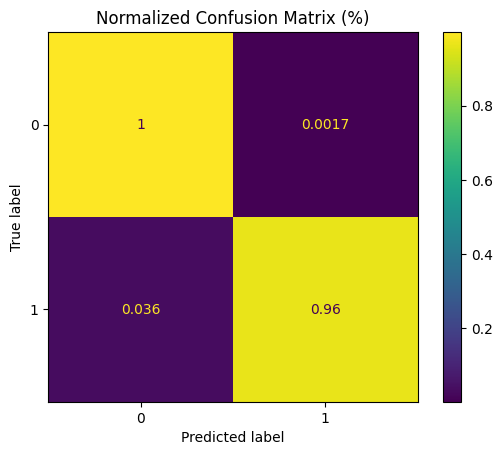

In [70]:
cm = confusion_matrix(y_test, y_pred_final, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Normalized Confusion Matrix (%)")
plt.show()